## Setup

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from torch import from_numpy, Tensor
from torchmetrics import MetricCollection
import torchmetrics
import torchmetrics.text
import evaluate

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from tqdm import tqdm

tqdm.pandas()

In [4]:
meteor = evaluate.load("meteor")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:
df = pd.read_hdf(Path("eval-all") / "data" / "all_joined_judged.h5")
df = df[df["sample_id"] >= 27000].copy()  # Only do this for samples from the test split
df

,setting,model,mode,sample_id,question_id,prediction_text,action_sequence,textual_description,question_type,question,answer_type,answer_text,answer,options,options_sequence,prediction_parsed_binary,prediction_parsed_multi,llm_judge_raw,llm_judge_rationale,llm_judge_score
30000,4.2.1,Falcon (7B),200,27000,0,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,right_after_open,"After engaging in bowing, what followed immedi...",open,Someone is waving.,NaN,NaN,NaN,NaN,NaN,"{\n\n ""BriefRationale"": ""The system_answer ...",The system_answer correctly identifies 'waving...,3
30001,4.2.1,Falcon (7B),200,27000,1,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,descriptive_identification_open,"At 2.803, what action is the person performing?",open,The person is bowing.,NaN,NaN,NaN,NaN,NaN,"{\n\n ""BriefRationale"": ""The system_answer ...",The system_answer incorrectly identifies the a...,1
30002,4.2.1,Falcon (7B),200,27000,2,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,descriptive_identification_multi,"What is the person doing at 4.354? A: waving, ...",multi,The correct answer is: waving.,0.0,"{'A': 'waving', 'B': 'bowing', 'C': 'picking s...","[waving, bowing, picking something up with bot...",NaN,A,<NA>,<NA>,<NA>
30003,4.2.1,Falcon (7B),200,27000,3,correct,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,count_binary,Is it accurate to state that the individual re...,binary,False,0.0,NaN,NaN,True,NaN,<NA>,<NA>,<NA>
30004,4.2.1,Falcon (7B),200,27000,4,"waving, picking something up with both hands, ...","{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,after_open,Following the performance of bowing by the per...,open,The subject is waving and picking something up...,NaN,NaN,NaN,NaN,NaN,"{""BriefRationale"": ""The system_answer correctl...",The system_answer correctly lists all actions ...,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777099,4.4,NeSy Qwen3 8B GT,full,29999,0,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_least_binary,"In terms of occurrence, was the person's invol...",binary,True,1.0,NaN,NaN,False,NaN,<NA>,<NA>,<NA>
2777100,4.4,NeSy Qwen3 8B GT,full,29999,1,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,comparison_first_last_same_binary,Are the initial and final actions identical to...,binary,No,0.0,NaN,NaN,False,NaN,<NA>,<NA>,<NA>
2777101,4.4,NeSy Qwen3 8B GT,full,29999,2,A,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,before_multi,Some time before the person performed playing ...,multi,The correct answer is picking something up wit...,0.0,"{'A': 'picking something up with both hands', ...","[picking something up with both hands, jumping...",NaN,A,<NA>,<NA>,<NA>
2777102,4.4,NeSy Qwen3 8B GT,full,29999,3,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_most_binary,Was kicking a ball the most frequently observe...,binary,This is not correct.,0.0,NaN,NaN,False,NaN,<NA>,<NA>,<NA>


## Compute Metrics

### Binary Tasks

In [6]:
binary = df[df["answer_type"] == "binary"].copy()
binary.drop(
    columns=["options", "options_sequence", "prediction_parsed_multi"], inplace=True
)
binary["prediction_parsed_binary"].fillna(np.nan, inplace=True)
binary = binary.astype({"answer": int, "prediction_parsed_binary": float}, copy=False)

In [7]:
def unwrap(res: dict[str, Tensor]) -> dict[str, float]:
    return {k: v.item() for k, v in res.items()}


def compute_binary_metrics(df: pd.DataFrame) -> dict[str, float]:
    metrics = MetricCollection(
        {
            "Accuracy": torchmetrics.Accuracy(task="binary"),
            "Precision": torchmetrics.Precision(task="binary"),
            "Recall": torchmetrics.Recall(task="binary"),
            "F1": torchmetrics.F1Score(task="binary", average="macro"),
        }
    )

    return unwrap(
        metrics(
            from_numpy(df["prediction_parsed_binary"].to_numpy(na_value=-1)),
            from_numpy(df["answer"].to_numpy()),
        )
    )


all_results_binary = (
    binary.groupby(["setting", "model", "mode"])
    .apply(compute_binary_metrics)
    .apply(pd.Series)
    .reset_index()
)
all_results_binary

,setting,model,mode,Accuracy,F1,Precision,Recall
0,4.2.1,Falcon (7B),200,0.601799,0.629432,0.596998,0.665594
1,4.2.1,Falcon (7B),250,0.557972,0.384703,0.657076,0.271967
2,4.2.1,Falcon (7B),350,0.546361,0.359945,0.635697,0.251046
3,4.2.1,Falcon (7B),400,0.547179,0.379843,0.624448,0.272932
4,4.2.1,Falcon (7B),full,0.962551,0.963494,0.954517,0.972642
...,...,...,...,...,...,...,...
66,4.3,Human,organic,0.775801,0.778947,0.812195,0.748315
67,4.4,NeSy Llama 3.1 8B AE,full,0.769419,0.755548,0.818865,0.701320
68,4.4,NeSy Llama 3.1 8B GT,full,0.769747,0.754875,0.822146,0.697779
69,4.4,NeSy Qwen3 8B AE,full,0.804906,0.777384,0.924956,0.670422


### Multi Tasks

In [8]:
multi = df[df["answer_type"] == "multi"].copy()
multi["prediction_parsed_multi"].fillna(np.nan, inplace=True)
multi.drop(columns=["prediction_parsed_binary"], inplace=True)

In [9]:
def compute_multi_metrics(df: pd.DataFrame) -> dict[str, float]:
    metrics = MetricCollection(
        {
            "Accuracy": torchmetrics.Accuracy(task="multiclass", num_classes=3),
            "Precision": torchmetrics.Precision(task="multiclass", num_classes=3),
            "Recall": torchmetrics.Recall(task="multiclass", num_classes=3),
            "F1": torchmetrics.F1Score(
                task="multiclass", num_classes=3, average="macro"
            ),
        }
    )

    ground_truth = df["answer"].to_numpy()

    predictions = (
        df["prediction_parsed_multi"]
        .map({"A": 0, "B": 1, "C": 2})
        .to_numpy(na_value=-1)
        .astype(np.int32)
    )
    # Make sure we put a wrong answer in case of NaN
    predictions[predictions == -1] = (ground_truth[predictions == -1] + 1) % 3

    return unwrap(
        metrics(
            from_numpy(predictions),
            from_numpy(ground_truth),
        )
    )


all_results_multi = (
    multi.groupby(["setting", "model", "mode"])
    .apply(compute_multi_metrics)
    .apply(pd.Series)
    .reset_index()
)
all_results_multi

,setting,model,mode,Accuracy,F1,Precision,Recall
0,4.2.1,Falcon (7B),200,0.596411,0.595906,0.596411,0.596411
1,4.2.1,Falcon (7B),250,0.676484,0.676226,0.676484,0.676484
2,4.2.1,Falcon (7B),350,0.606995,0.606749,0.606995,0.606995
3,4.2.1,Falcon (7B),400,0.469397,0.467880,0.469397,0.469397
4,4.2.1,Falcon (7B),full,0.995858,0.995852,0.995858,0.995858
...,...,...,...,...,...,...,...
66,4.3,Human,organic,0.865854,0.865448,0.865854,0.865854
67,4.4,NeSy Llama 3.1 8B AE,full,0.675334,0.671513,0.675334,0.675334
68,4.4,NeSy Llama 3.1 8B GT,full,0.672342,0.668248,0.672342,0.672342
69,4.4,NeSy Qwen3 8B AE,full,0.855039,0.855003,0.855039,0.855039


### Open Tasks

In [10]:
open = df[df["answer_type"] == "open"].copy()
open.drop(
    columns=[
        "prediction_parsed_binary",
        "options",
        "answer",
        "options_sequence",
        "prediction_parsed_multi",
    ],
    inplace=True,
)

In [9]:
def compute_open_metrics(df: pd.DataFrame) -> dict[str, float]:
    inputs = (
        df["prediction_text"].fillna(""),
        df["answer_text"],
    )

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", category=FutureWarning, module="torch.nn.modules.module"
        )

        return {
            "BLEU": torchmetrics.text.BLEUScore()(*inputs).item(),
            "ROUGE": torchmetrics.text.ROUGEScore(
                use_stemmer=True, rouge_keys=("rouge1",)
            )(*inputs)["rouge1_fmeasure"].item(),
            "METEOR": meteor.compute(
                predictions=inputs[0].tolist(),
                references=inputs[1].tolist(),
            )["meteor"],
            "BERTScore": (
                torchmetrics.text.BERTScore(
                    model_name_or_path="roberta-large",
                    lang="en",
                    device="cuda",
                    batch_size=512,
                )(*inputs)["f1"]
                .mean()
                .item()
            ),
            "LLMJudge": df["llm_judge_score"].fillna(1).mean(),
        }


all_results_open = (
    open.groupby(["setting", "model", "mode"])
    .progress_apply(compute_open_metrics)
    .apply(pd.Series)
    .reset_index()
)
all_results_open

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
100%|██████████| 71/71 [22:41<00:00, 19.17s/it]


,setting,model,mode,BLEU,ROUGE,METEOR,BERTScore,LLMJudge
0,4.2.1,Falcon (7B),200,0.0,0.198666,0.282416,0.972116,2.020048
1,4.2.1,Falcon (7B),250,0.0,0.214915,0.331673,0.972199,2.158185
2,4.2.1,Falcon (7B),350,0.0,0.203923,0.329550,0.971975,2.117427
3,4.2.1,Falcon (7B),400,0.0,0.203032,0.272586,0.972387,2.047147
4,4.2.1,Falcon (7B),full,0.0,0.335013,0.505252,0.972474,2.880370
...,...,...,...,...,...,...,...,...
66,4.3,Human,organic,0.0,0.095508,0.263357,0.975578,2.231293
67,4.4,NeSy Llama 3.1 8B AE,full,0.0,0.129803,0.364941,0.972535,2.415951
68,4.4,NeSy Llama 3.1 8B GT,full,0.0,0.132120,0.367441,0.972597,2.411765
69,4.4,NeSy Qwen3 8B AE,full,0.0,0.148417,0.362943,0.973569,2.597709


## Save / Load metrics

In [ ]:
all_results_binary.to_csv(
    Path("eval-all") / "data" / "all_results_binary.csv", index=False
)
all_results_multi.to_csv(
    Path("eval-all") / "data" / "all_results_multi.csv", index=False
)
all_results_open.to_csv(Path("eval-all") / "data" / "all_results_open.csv", index=False)

In [11]:
all_results_binary = pd.read_csv(Path("eval-all") / "data" / "all_results_binary.csv")
all_results_multi = pd.read_csv(Path("eval-all") / "data" / "all_results_multi.csv")
all_results_open = pd.read_csv(Path("eval-all") / "data" / "all_results_open.csv")

## Prepare results for paper

In [40]:
relevant_models = [
    # "Mistral (7B)",
    # "Gemma (2B)",
    "Gemma 7B",
    "Llama 3.1 8B",
    # "Llama 3 (8B)",
    # "Llama 2 (8B)",
    # "Falcon 2 (11B)",
    # "Falcon (7B)",
    "T5 Base",
    # "T5 Small",
]

### For Section 4.2.1

<Figure size 800x600 with 0 Axes>

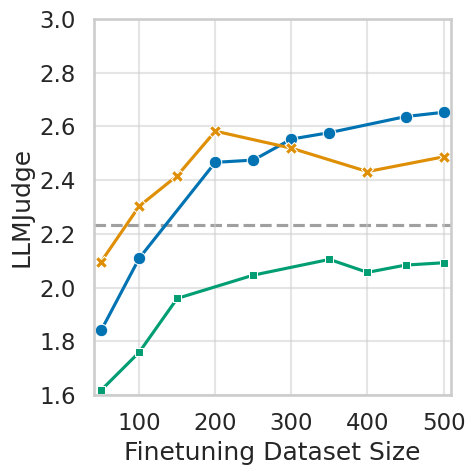

In [55]:
setting = "4.2.1"

# # variant = "binary"
# # df = all_results_binary.copy()
# # human_baseline = 77.89
# variant = "multi"
# df = all_results_multi.copy()
# human_baseline = 86.54
# metrics = ["Accuracy", "Precision", "Recall", "F1"]
# metric = metrics[3]
# ymin, ymax = None, 100
# in_percent = True

variant = "open"
df = all_results_open.copy()
human_baseline = 2.2313
metrics = ["BLEU", "ROUGE", "METEOR", "BERTScore", "LLMJudge"]
metric = metrics[4]
ymin, ymax = 1.6, 3.0
in_percent = False

df["model"] = df["model"].replace(
    {
        "Gemma (7B)": "Gemma 7B",
        "Llama 3.1 (8B)": "Llama 3.1 8B",
    }
)
df = df[df["model"].isin(relevant_models)]
df = df[df["setting"] == setting].copy()
df["mode"] = df["mode"].astype(str)
modes_sorted = sorted(
    [m for m in df["mode"].unique() if m != "full"], key=lambda x: int(x)
) + ["full"]
# Exclude "full" for now
modes_sorted = modes_sorted[:-1]
df = df[df["mode"].isin(modes_sorted)].copy()
df["mode"] = df["mode"].astype(int)
# df["mode"] = pd.Categorical(df["mode"], categories=modes_sorted, ordered=True)

sns.set_style("whitegrid")
sns.set_context("talk")

if in_percent:
    df[metric] *= 100

plt.figure(figsize=(8, 6))
grid = sns.relplot(
    data=df.rename(columns={"model": "Model"}),
    x="mode",
    y=metric,
    hue="Model",
    style="Model",
    kind="line",
    markers=True,
    dashes=False,
    hue_order=relevant_models,
    # legend="auto",
    legend=False,
    palette="colorblind",
)

# Add the human baseline in the background
plt.axhline(
    y=human_baseline, color="gray", alpha=0.75, linestyle="--", label="Humans", zorder=0
)

# Add a new legend containing the human baseline
# grid.legend.remove()
# plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xlabel("Finetuning Dataset Size")
# plt.xlim(0, len(modes_sorted) - 1)
plt.xlim(min(df["mode"]) - 10, max(df["mode"]) + 10)

plt.ylabel(metric)
plt.ylim(ymin, ymax)
if in_percent:
    # Add percentage signs to y-ticks
    plt.gca().set_yticklabels([f"{y.get_text()}%" for y in plt.gca().get_yticklabels()])

plt.grid(True, linestyle="-", alpha=0.5)

sns.despine(top=False, right=False)

plt.savefig(
    Path("eval-all") / "plots" / f"{variant}_{metric.lower()}.pdf",
    bbox_inches="tight",
    pad_inches=0,
)
plt.show()

### For Section 4.2.1 - 4.2.4

In [14]:
df = all_results_binary
df = df[df["model"].isin(["Llama 3.1 (8B)"])]
df = df[(df["setting"] != "4.2.1") | (df["mode"] == "full")]
df = df[df["setting"].isin(["4.2.1", "4.2.2", "4.2.3", "4.2.4"])].copy()
df = df.set_index(["setting", "model", "mode"]) * 100
print(df)

                              Accuracy         F1  Precision     Recall
setting model          mode                                            
4.2.1   Llama 3.1 (8B) full  99.100572  99.118167  98.753995  99.485034
4.2.2   Llama 3.1 (8B) full  55.224860  50.719941  57.533687  45.349211
4.2.3   Llama 3.1 (8B) 50    48.487327  35.582823  48.794168  28.001288
4.2.4   Llama 3.1 (8B) 50    49.795586  51.176846  50.581580  51.786292


In [15]:
df = all_results_multi
df = df[df["model"].isin(["Llama 3.1 (8B)"])]
df = df[(df["setting"] != "4.2.1") | (df["mode"] == "full")]
df = df[df["setting"].isin(["4.2.1", "4.2.2", "4.2.3", "4.2.4"])].copy()
df = df.set_index(["setting", "model", "mode"]) * 100
print(df)

                              Accuracy         F1  Precision     Recall
setting model          mode                                            
4.2.1   Llama 3.1 (8B) full  99.976993  99.976790  99.976993  99.976993
4.2.2   Llama 3.1 (8B) full  64.473081  64.383233  64.473081  64.473081
4.2.3   Llama 3.1 (8B) 50     9.687068   9.616224   9.687068   9.687068
4.2.4   Llama 3.1 (8B) 50     0.276116   0.276616   0.276116   0.276116


In [16]:
df = all_results_open
df = df[df["model"].isin(["Llama 3.1 (8B)"])]
df = df[(df["setting"] != "4.2.1") | (df["mode"] == "full")]
df = df[df["setting"].isin(["4.2.1", "4.2.2", "4.2.3", "4.2.4"])].copy()
df = df.set_index(["setting", "model", "mode"])
print(df)

                             BLEU     ROUGE    METEOR  BERTScore  LLMJudge
setting model          mode                                               
4.2.1   Llama 3.1 (8B) full   0.0  0.337951  0.509947   0.972418  2.886759
4.2.2   Llama 3.1 (8B) full   0.0  0.205281  0.243621   0.969019  2.204230
4.2.3   Llama 3.1 (8B) 50     0.0  0.060323  0.057573   0.968770  1.092091
4.2.4   Llama 3.1 (8B) 50     0.0  0.027397  0.015414   0.968260  1.034589


### For Section 4.3 / 4.4

In [17]:
print(
    (
        all_results_binary[
            all_results_binary["setting"].isin(["4.3", "4.4"])
        ].set_index(["setting", "model", "mode"])
        * 100
    ).to_string()
)

                                       Accuracy         F1  Precision     Recall
setting model                mode                                               
4.3     Human                organic  77.580070  77.894735  81.219512  74.831462
4.4     NeSy Llama 3.1 8B AE full     76.941943  75.554782  81.886506  70.131958
        NeSy Llama 3.1 8B GT full     76.974654  75.487465  82.214636  69.777918
        NeSy Qwen3 8B AE     full     80.490595  77.738386  92.495561  67.042160
        NeSy Qwen3 8B GT     full     80.408829  77.665919  92.290652  67.042160


In [18]:
print(
    (
        all_results_multi[all_results_multi["setting"].isin(["4.3", "4.4"])].set_index(
            ["setting", "model", "mode"]
        )
        * 100
    ).to_string()
)

                                       Accuracy         F1  Precision     Recall
setting model                mode                                               
4.3     Human                organic  86.585367  86.544788  86.585367  86.585367
4.4     NeSy Llama 3.1 8B AE full     67.533362  67.151290  67.533362  67.533362
        NeSy Llama 3.1 8B GT full     67.234236  66.824770  67.234236  67.234236
        NeSy Qwen3 8B AE     full     85.503912  85.500288  85.503912  85.503912
        NeSy Qwen3 8B GT     full     85.618961  85.616297  85.618961  85.618961


In [19]:
print(
    (
        all_results_open[all_results_open["setting"].isin(["4.3", "4.4"])].set_index(
            ["setting", "model", "mode"]
        )
    ).to_string()
)

                                      BLEU     ROUGE    METEOR  BERTScore  LLMJudge
setting model                mode                                                  
4.3     Human                organic   0.0  0.095508  0.263357   0.975578  2.231293
4.4     NeSy Llama 3.1 8B AE full      0.0  0.129803  0.364941   0.972535  2.415951
        NeSy Llama 3.1 8B GT full      0.0  0.132120  0.367441   0.972597  2.411765
        NeSy Qwen3 8B AE     full      0.0  0.148417  0.362943   0.973569  2.597709
        NeSy Qwen3 8B GT     full      0.0  0.148094  0.363821   0.973742  2.598810
